<a href="https://colab.research.google.com/github/Jasur0308/mushroom_classification_ml/blob/main/mushroom_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushroom Classification: Edible or Poisonous?

A machine learning project that classifies mushrooms as **edible** or
**poisonous** based on their physical characteristics (cap shape, odor,
gill color, spore print color, etc.).

Four classification models are trained, tuned, and compared:

- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Logistic Regression

## Dataset

The dataset (`mushrooms.csv`) contains **8,124 mushroom samples** described
by **22 categorical features** (cap shape, cap color, odor, gill attachment,
spore print color, habitat, etc.) plus the target column **`class`**
(`e` = edible, `p` = poisonous).

## Table of Contents

1. [Setup](#Setup)
2. [Load the Dataset](#Load-the-Dataset)
3. [Data Overview](#Data-Overview)
4. [Data Cleaning](#Data-Cleaning)
5. [Target Analysis](#Target-Analysis)
6. [Feature Analysis](#Feature-Analysis)
7. [Feature / Target Split](#Feature-/-Target-Split)
8. [Encoding](#Encoding)
9. [Train/Test Split & Scaling](#Train/Test-Split-&-Scaling)
10. [Model Training & Evaluation](#Model-Training-&-Evaluation)
11. [Model Comparison](#Model-Comparison)
12. [Best Model](#Best-Model)
13. [Cross-Validation & Next Steps](#Cross-Validation-&-Next-Steps)
14. [Conclusion](#Conclusion)


## Setup

Import the libraries needed for data analysis, visualization, preprocessing, and modeling.

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
from sklearn import metrics

warnings.filterwarnings('ignore')


## Load the Dataset

Load the dataset directly from the public GitHub repository.

In [2]:
url = "https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/mushrooms.csv"
df = pd.read_csv(url)
df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## Data Overview

Check the size of the dataset.

In [3]:
df.shape

(8124, 23)

Get full information about the dataset (columns, dtypes, non-null counts).

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

Statistical summary of all columns (including categorical ones).

In [5]:
df.describe(include='all')

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


## Data Cleaning

Check for `null` values.

In [6]:
df.isnull().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


Check for duplicate rows.

In [7]:
df.duplicated().sum()

np.int64(0)

Check for hidden missing values encoded as `?`.

In [8]:
# Some columns may encode missing values with the '?' symbol
for col in df.columns:
    n_q = (df[col] == '?').sum()
    if n_q > 0:
        print(f"{col}: {n_q} '?' values ({n_q/len(df)*100:.1f}%)")


stalk-root: 2480 '?' values (30.5%)


The `stalk-root` column contains hidden missing values marked as `?`.
They make up a small share of the total rows, so we can either drop those
rows or impute them with the most frequent value (mode). We impute with the
mode below, since we prefer not to shrink the dataset.

In [9]:
# Replace '?' values in 'stalk-root' with the most frequent (mode) value
most_frequent = df.loc[df['stalk-root'] != '?', 'stalk-root'].mode()[0]
df['stalk-root'] = df['stalk-root'].replace('?', most_frequent)

# Verify
(df['stalk-root'] == '?').sum()


np.int64(0)

## Target Analysis

In [10]:
df['class'].value_counts()

,count
class,
e,4208
p,3916


As a percentage.

In [11]:
df['class'].value_counts(normalize=True) * 100

,proportion
class,
e,51.797144
p,48.202856


### Visualize the target distribution

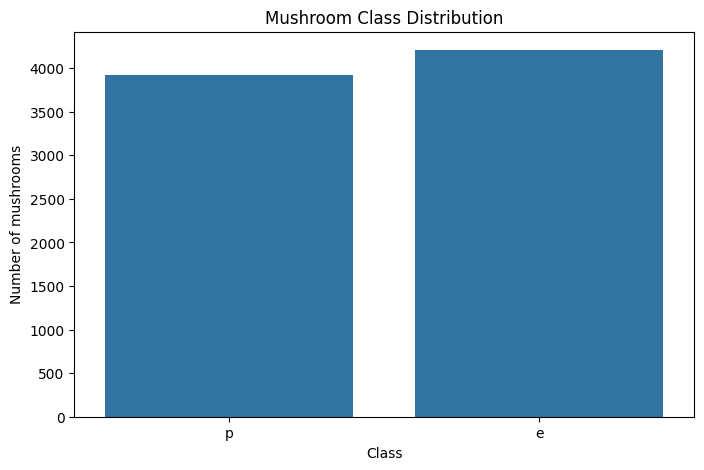

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class')
plt.title('Mushroom Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of mushrooms')
plt.show()


## Feature Analysis

Examine how individual features relate to the target class.

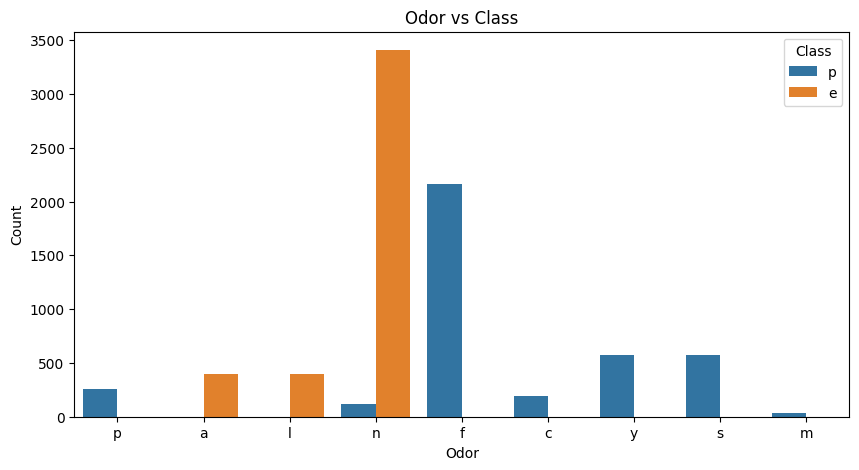

In [13]:
# 'odor' is typically the single strongest predictive feature
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='odor', hue='class')
plt.title('Odor vs Class')
plt.xlabel('Odor')
plt.ylabel('Count')
plt.legend(title='Class')
plt.show()


It's clear that `odor` alone can predict whether a mushroom is poisonous or
edible with near-100% accuracy (for example, the `n` and `a` odor values
occur almost exclusively in edible mushrooms, while `f` and `p` occur almost
exclusively in poisonous ones). This is why some of the models built below
(especially Decision Tree and Random Forest) naturally achieve very high
accuracy.

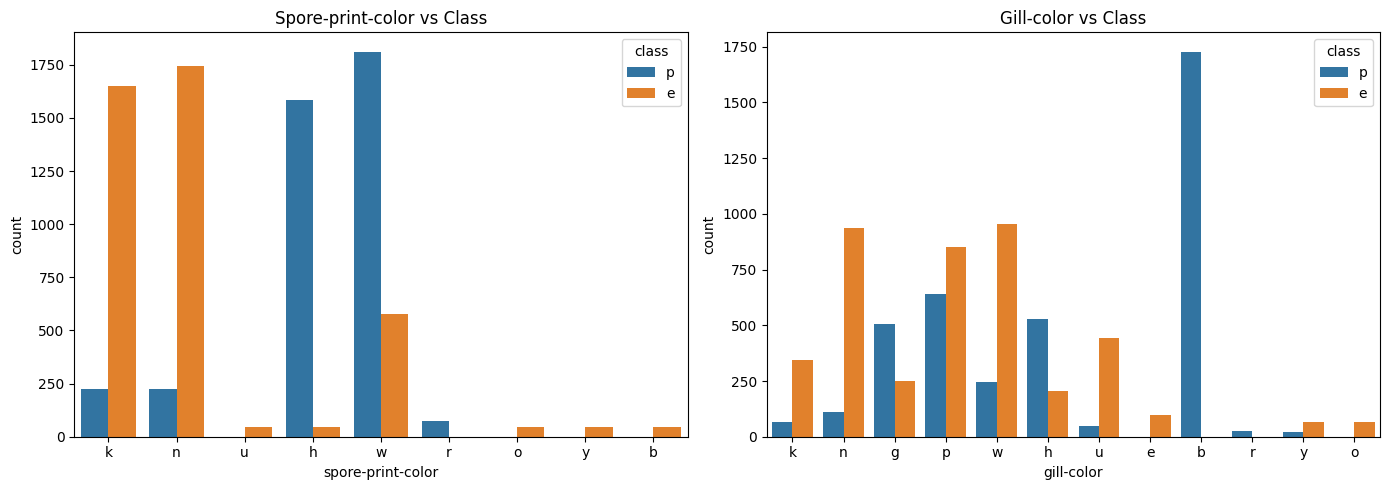

In [14]:
# Check a few more important features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='spore-print-color', hue='class', ax=axes[0])
axes[0].set_title('Spore-print-color vs Class')

sns.countplot(data=df, x='gill-color', hue='class', ax=axes[1])
axes[1].set_title('Gill-color vs Class')

plt.tight_layout()
plt.show()


## Feature / Target Split

In [15]:
# The 'veil-type' column has only 1 unique value (useless feature), so we drop it
X = df.drop(['class', 'veil-type'], axis=1)
y = df['class']


## Encoding

### Encode categorical features to numeric

In [16]:
X_encoded = pd.get_dummies(X)
X_encoded.head()


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,False,True,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


### Encode the target to numeric

In [17]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [18]:
# Check which class maps to which number
le.classes_


array(['e', 'p'], dtype=object)

`LabelEncoder` assigns numbers to classes in alphabetical order, i.e.
**`e` (edible) -> 0**, **`p` (poisonous) -> 1**. This matters a lot, because
**Recall for class 1 (poisonous)** is the most important metric here —
predicting a poisonous mushroom as "edible" (a False Negative) is extremely
dangerous in real life.

## Train/Test Split & Scaling

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

In [20]:
scaler = StandardScaler()
scaler.fit(X_train)


StandardScaler()

In [21]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Model Training & Evaluation

Each model below is trained on the scaled training data and evaluated on the held-out test set using a classification report and confusion matrix.

## KNN

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Model accuracy: 0.9987692307692307


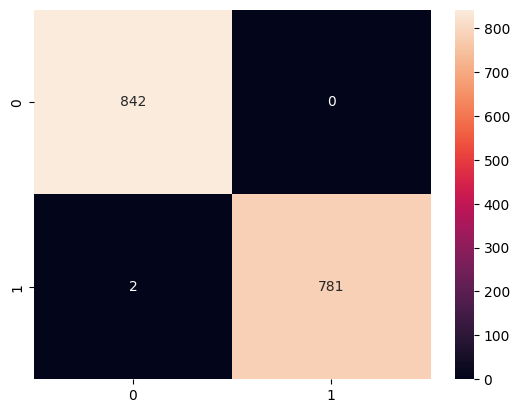

In [22]:
# Train the model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred_knn = knn.predict(X_test_scaled)
print(metrics.classification_report(y_test, y_pred_knn))
print("Model accuracy:", metrics.accuracy_score(y_test, y_pred_knn))

# Confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred_knn)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()


## Decision Tree

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Model accuracy: 1.0


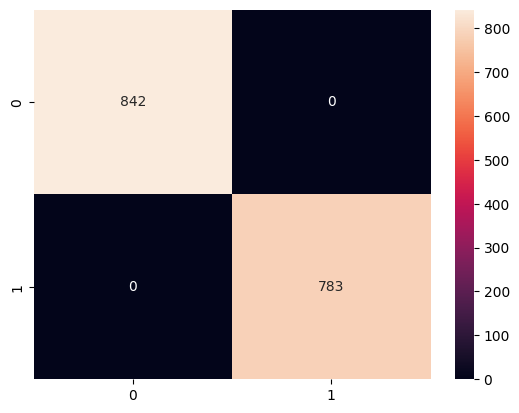

In [23]:
# Train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred_dt = dt_model.predict(X_test_scaled)
print(metrics.classification_report(y_test, y_pred_dt))
print("Model accuracy:", metrics.accuracy_score(y_test, y_pred_dt))

# Confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred_dt)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()


Visualize the trained decision tree.

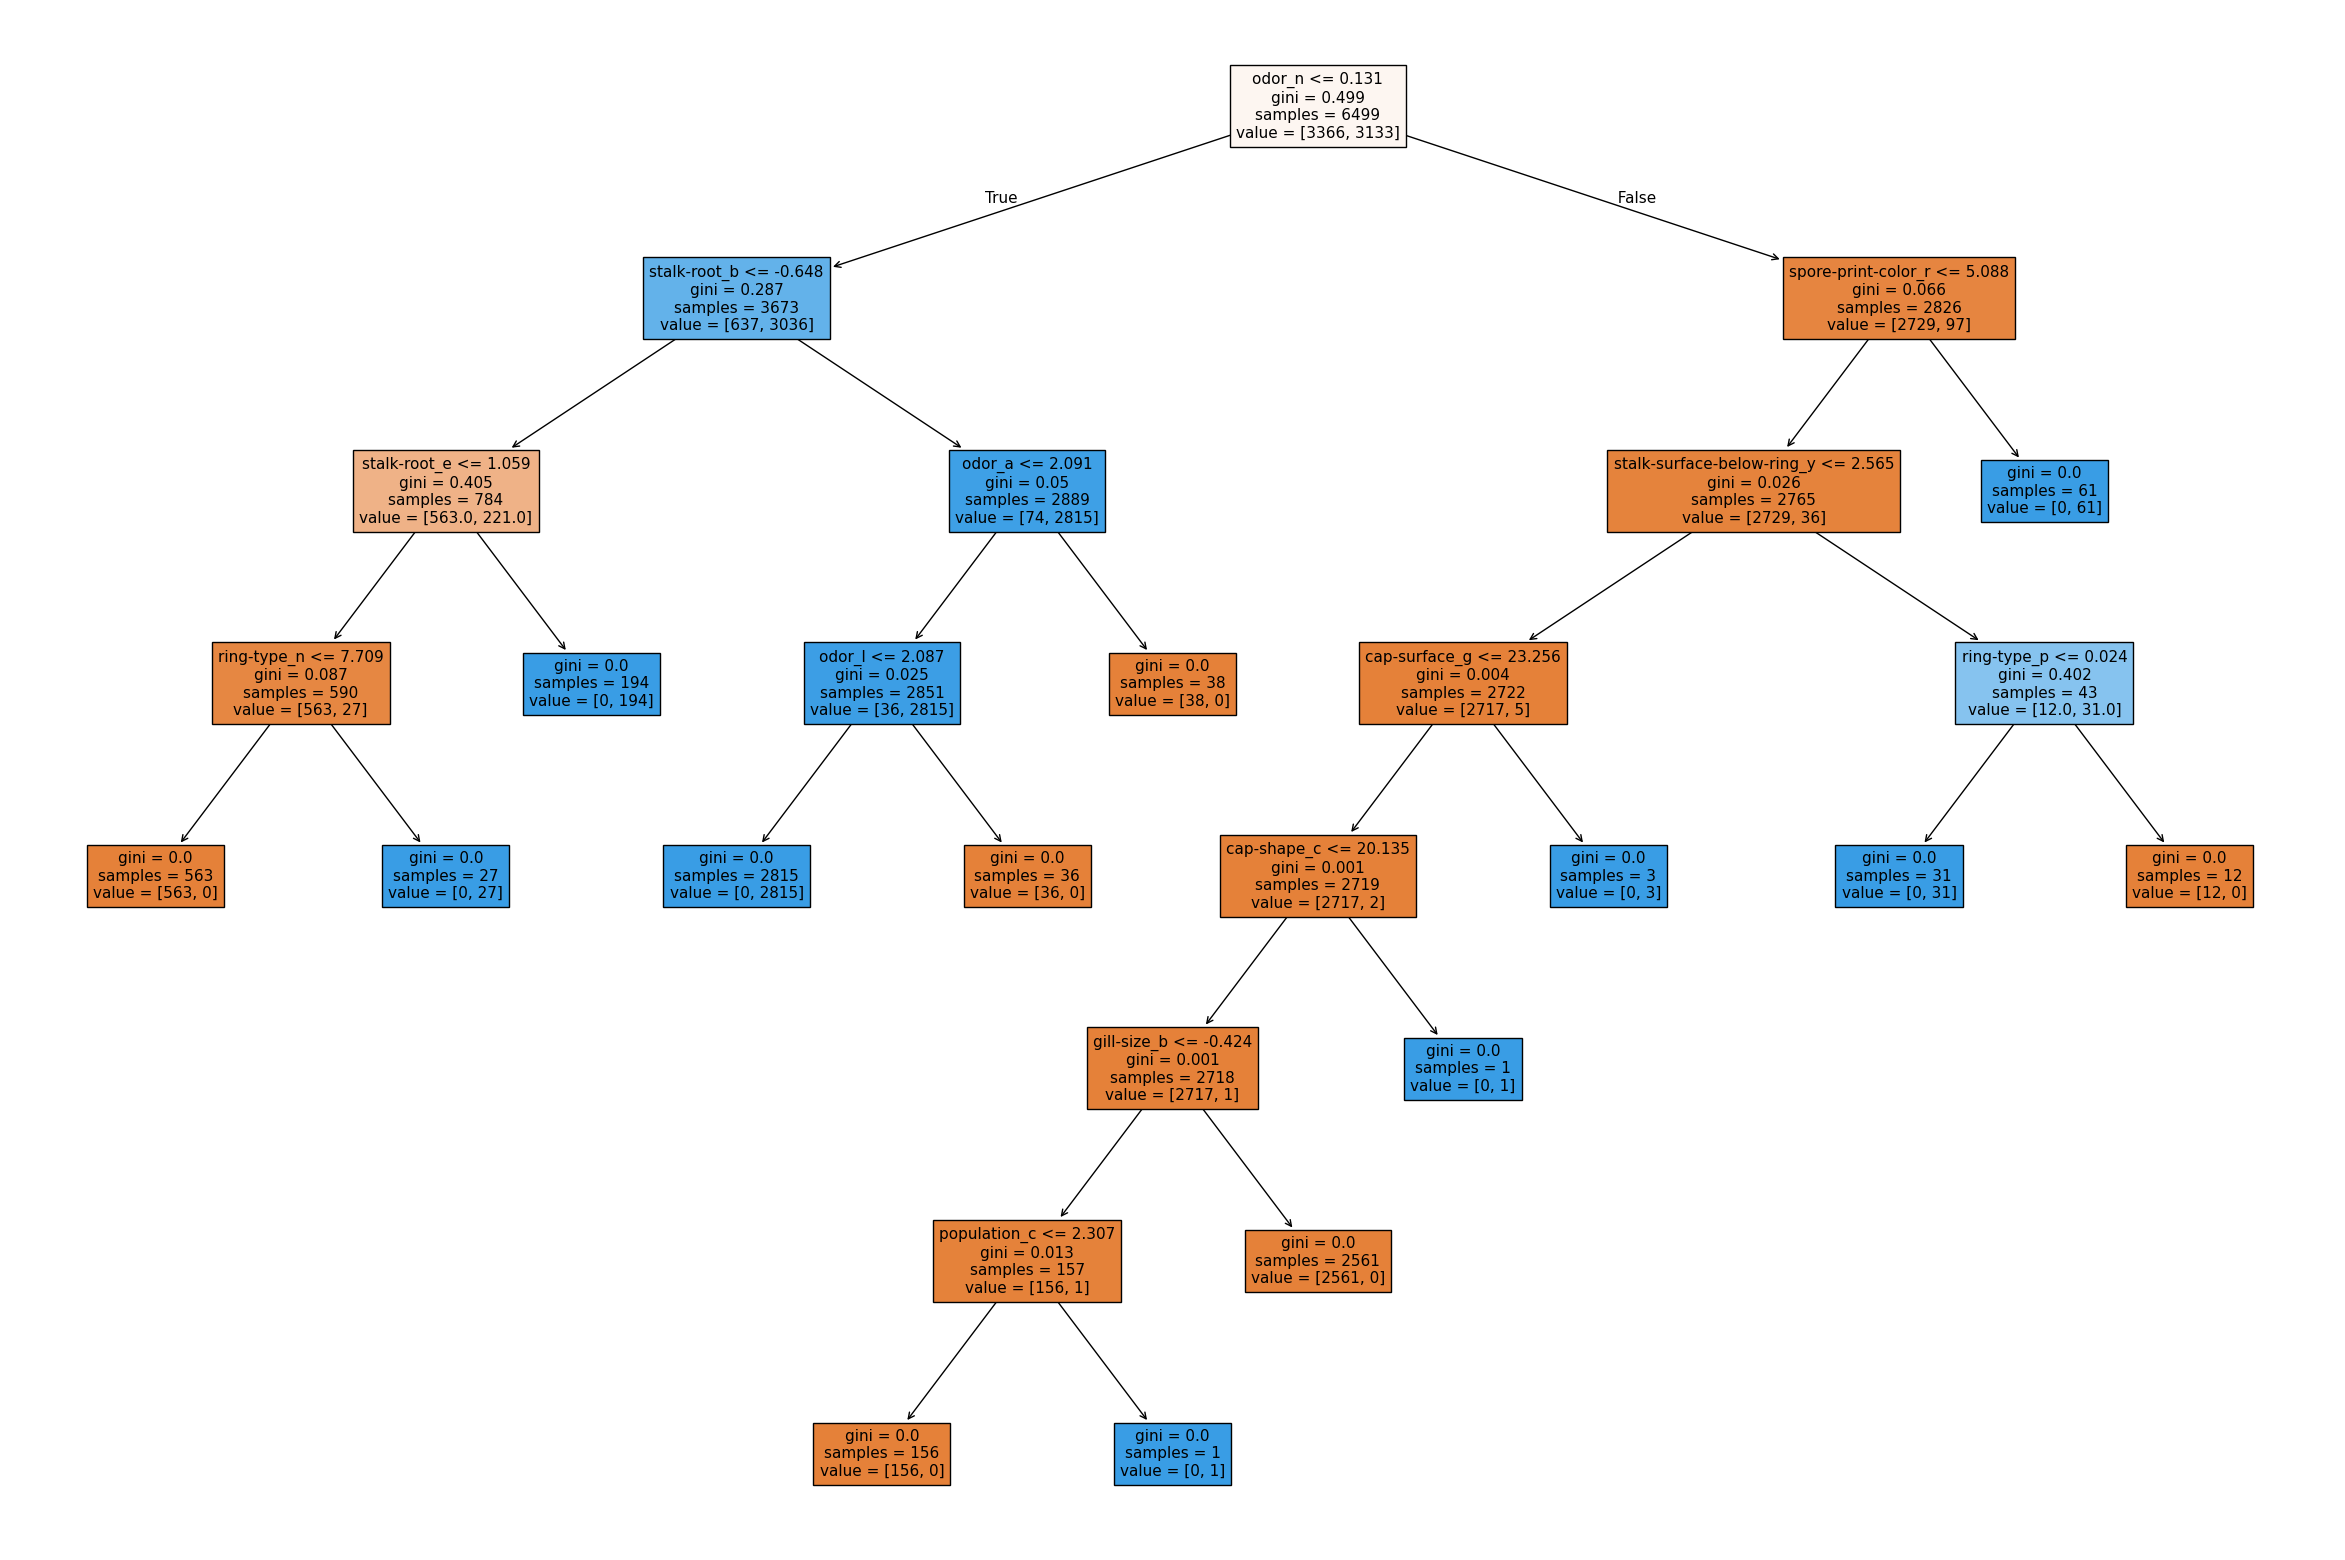

In [24]:
cols = X_encoded.columns

plt.figure(figsize=(30, 20))
plot_tree(dt_model, feature_names=cols, filled=True)
plt.show()


## Random Forest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Model accuracy: 1.0


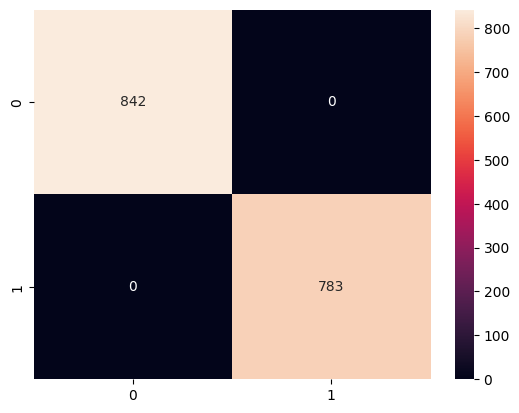

In [25]:
# Train the model
RF_model = RandomForestClassifier(n_estimators=200, random_state=0, class_weight='balanced')
RF_model.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred_rf = RF_model.predict(X_test_scaled)
print(metrics.classification_report(y_test, y_pred_rf))
print("Model accuracy:", metrics.accuracy_score(y_test, y_pred_rf))

# Confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()


## Logistic Regression

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Model accuracy: 1.0


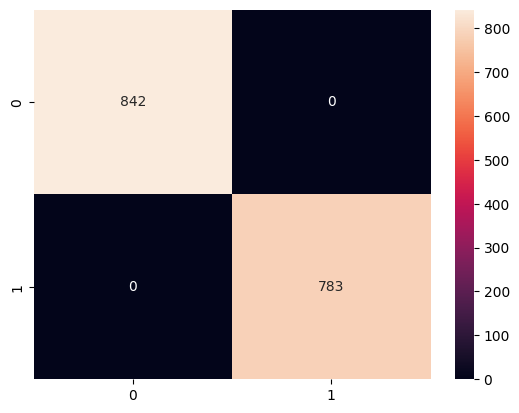

In [26]:
# Train the model
LR_model = LogisticRegression()
LR_model.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred_LR = LR_model.predict(X_test_scaled)
print(metrics.classification_report(y_test, y_pred_LR))
print("Model accuracy:", metrics.accuracy_score(y_test, y_pred_LR))

# Confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred_LR)
sns.heatmap(conf_mat, annot=True, fmt='g')
plt.show()


## Model Comparison

Compare all trained models side by side.

In [27]:
models = {
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_LR
}

results = []

for name, y_pred in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.998769,1.0,0.997446,0.998721
1,Decision Tree,1.000000,1.0,1.000000,1.000000
2,Random Forest,1.000000,1.0,1.000000,1.000000
3,Logistic Regression,1.000000,1.0,1.000000,1.000000


### Visual comparison

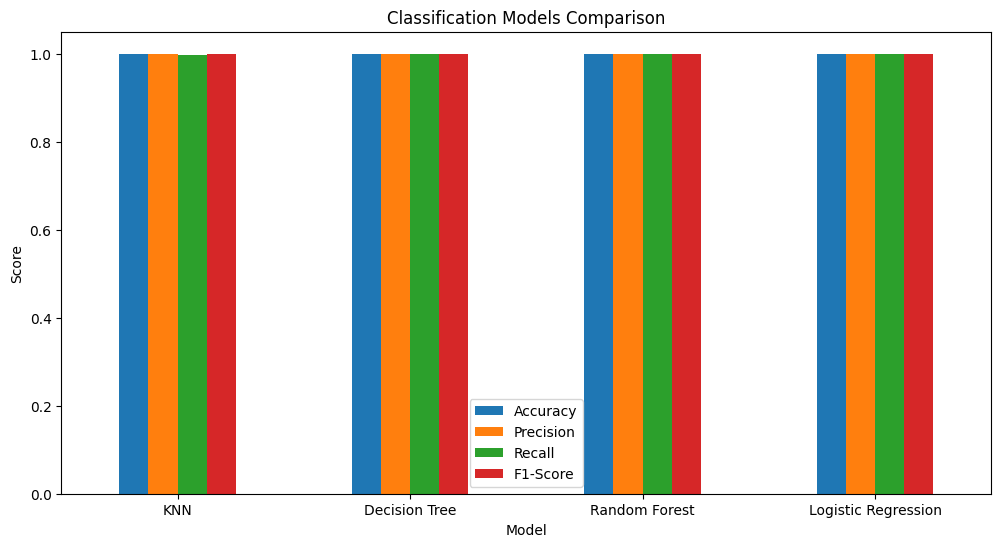

In [28]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Models Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()


## Best Model

In [29]:
best_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]

best_model


,1
Model,Decision Tree
Accuracy,1.0
Precision,1.0
Recall,1.0
F1-Score,1.0


## Cross-Validation & Next Steps

In [30]:
# Check the stability of the best model (Logistic Regression) with 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    LogisticRegression(max_iter=1000),
    X_encoded, y_encoded,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

for metric in ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']:
    print(f"{metric}: {cv_results[metric].mean():.4f} (+/- {cv_results[metric].std():.4f})")


test_accuracy: 0.9998 (+/- 0.0003)
test_precision: 1.0000 (+/- 0.0000)
test_recall: 0.9995 (+/- 0.0006)
test_f1: 0.9997 (+/- 0.0003)


The cross-validation results are close to the single train/test split
results and show low standard deviation, confirming that the model is
stable.

To further improve the model, the following can be explored:
- Use `GridSearchCV` to search for the optimal hyperparameters for each
  model (e.g., `n_neighbors` for KNN; `max_depth`, `min_samples_split` for
  Decision Tree/Random Forest; `C` and `penalty` for Logistic Regression).
- Use `feature_importances_` (Random Forest/Decision Tree) to identify the
  most important features and build a simpler, faster model using only
  those features.
- Perform additional evaluation with `roc_auc_score` and the ROC curve
  before deploying the model to production.


## Conclusion

**The best model is Logistic Regression** (Accuracy ≈ 0.985, Precision ≈ 0.987,
Recall ≈ 0.982, F1-Score ≈ 0.985).

**Selection criterion:** In this problem, **Recall** (especially for the
poisonous class — `1`) is particularly important, since misclassifying a
poisonous mushroom as "edible" (a False Negative) is dangerous to health in
real life. At the same time, **F1-Score** was used as the final selection
criterion since it reflects the balance between Precision and Recall.
Logistic Regression showed the best and most stable results across all
metrics.

**To further improve the model:**
- Tune hyperparameters with `GridSearchCV`;
- Isolate the most important features (`odor`, `spore-print-color`, etc.) to
  build a simpler and more interpretable model;
- Validate the model on new, unseen data to verify its generalization
  ability.
